<a href="https://colab.research.google.com/github/nikhilnigam11/Sales-Summary-using-SQLite-/blob/main/Sales_Summary_using_SQLite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Author: Nikhil Kumar Nigam**

Email: nikhilnigam@engineer.com

Task 7 at Elevate Labs

In [1]:
# Importing Pandas and sqlite
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect('superstore.db')  # Creating a database

In [3]:
data = pd.read_csv('/content/superstore.csv')
data.to_sql('superstore', conn, if_exists='replace', index=False)  # Converting csv file to sql

51290

In [11]:
# Querying the database
query = "SELECT * from superstore"
df = pd.read_sql(query, conn)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [12]:
query = "SELECT * FROM superstore"  # Quering the Data Table
df = pd.read_sql(query, conn)
df

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,2014-12-03 00:00:00.000,CA-2014-109701,...,69,Corporate,2014-12-04 00:00:00.000,Same Day,5.15,California,Binders,2014,North America,49
51286,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,2014-12-03 00:00:00.000,CA-2014-109701,...,9,Corporate,2014-12-04 00:00:00.000,Same Day,0.44,California,Binders,2014,North America,49
51287,Office Supplies,Los Angeles,United States,HR-147704,Hallie Redmond,0.2,US,1,2014-12-18 00:00:00.000,CA-2014-106964,...,12,Home Office,2014-12-21 00:00:00.000,First Class,0.31,California,Binders,2014,North America,51
51288,Office Supplies,Los Angeles,United States,RM-196754,Robert Marley,0.2,US,1,2014-12-25 00:00:00.000,CA-2014-145219,...,90,Home Office,2014-12-26 00:00:00.000,First Class,15.95,California,Binders,2014,North America,52


In [13]:
# quering Total Sales Amount from superstore

query1 = "SELECT Sum(Sales) as Total_Sales FROM superstore"
df1 = pd.read_sql(query1, conn)
df1

,Total_Sales
0,12642905


In [16]:
# quering Total Profit from superstore

query2 = "SELECT Sum(Profit) as Total_Profit FROM superstore"
df2 = pd.read_sql(query2, conn)
df2


,Total_Profit
0,1.467457e+06


In [20]:
# quering the Product with Max Quantity sold
query3 = '''SELECT `Product.Name` as Product, MAX(Quantity) as Max_Quantity
            FROM superstore
            GROUP BY `Product.Name`
            ORDER BY Max_Quantity DESC
            LIMIT 1;'''
df3 = pd.read_sql(query3, conn)
df3

,Product,Max_Quantity
0,Xerox 1964,14


In [21]:
# Superstores in Los Angeles

query4 = "SELECT * FROM superstore where City = 'Los Angeles'"
df4 = pd.read_sql(query4, conn)
df4


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,2014-12-03 00:00:00.000,CA-2014-109701,...,69,Corporate,2014-12-04 00:00:00.000,Same Day,5.15,California,Binders,2014,North America,49
743,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,2014-12-03 00:00:00.000,CA-2014-109701,...,9,Corporate,2014-12-04 00:00:00.000,Same Day,0.44,California,Binders,2014,North America,49
744,Office Supplies,Los Angeles,United States,HR-147704,Hallie Redmond,0.2,US,1,2014-12-18 00:00:00.000,CA-2014-106964,...,12,Home Office,2014-12-21 00:00:00.000,First Class,0.31,California,Binders,2014,North America,51
745,Office Supplies,Los Angeles,United States,RM-196754,Robert Marley,0.2,US,1,2014-12-25 00:00:00.000,CA-2014-145219,...,90,Home Office,2014-12-26 00:00:00.000,First Class,15.95,California,Binders,2014,North America,52


In [23]:
query5 = "SELECT * from superstore where Category = 'Technology'"
df5 = pd.read_sql(query5, conn)
df5

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Technology,Vinnytsya,Ukraine,RD-99002,Ruben Dartt,0.0,EMEA,1,2011-03-01 00:00:00.000,UP-2011-3730,...,1471,Consumer,2011-03-05 00:00:00.000,Standard Class,146.550,Vinnytsya,Accessories,2011,EMEA,10
1,Technology,Marseille,France,JW-160752,Julia West,0.0,EU,1,2011-04-11 00:00:00.000,ES-2011-3376060,...,294,Consumer,2011-04-16 00:00:00.000,Standard Class,14.910,Provence-Alpes-Côte d'Azur,Accessories,2011,EU,16
2,Technology,São Paulo,Brazil,CR-126253,Corey Roper,0.0,LATAM,1,2011-05-24 00:00:00.000,MX-2011-148033,...,201,Home Office,2011-05-28 00:00:00.000,Standard Class,14.911,São Paulo,Accessories,2011,LATAM,22
3,Technology,Naples,Italy,JC-161052,Julie Creighton,0.0,EU,1,2011-05-25 00:00:00.000,IT-2011-1780558,...,698,Corporate,2011-05-29 00:00:00.000,Standard Class,42.030,Campania,Accessories,2011,EU,22
4,Technology,Ludhiana,India,AG-104951,Andrew Gjertsen,0.0,APAC,1,2011-05-26 00:00:00.000,IN-2011-74994,...,185,Corporate,2011-05-31 00:00:00.000,Standard Class,13.480,Punjab,Accessories,2011,APAC,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10136,Technology,Los Angeles,United States,MG-181454,Mike Gockenbach,0.2,US,1,2014-10-08 00:00:00.000,CA-2014-108574,...,80,Consumer,2014-10-12 00:00:00.000,Standard Class,4.780,California,Phones,2014,North America,41
10137,Technology,Los Angeles,United States,JM-156554,Jim Mitchum,0.2,US,1,2014-10-28 00:00:00.000,CA-2014-151225,...,72,Corporate,2014-10-30 00:00:00.000,First Class,16.160,California,Phones,2014,North America,44
10138,Technology,Los Angeles,United States,DO-136454,Doug O'Connell,0.2,US,1,2014-11-28 00:00:00.000,CA-2014-133207,...,58,Consumer,2014-12-04 00:00:00.000,Standard Class,0.920,California,Phones,2014,North America,48
10139,Technology,Los Angeles,United States,FP-143204,Frank Preis,0.2,US,1,2014-12-08 00:00:00.000,CA-2014-137099,...,374,Consumer,2014-12-11 00:00:00.000,First Class,26.190,California,Phones,2014,North America,50


In [49]:
#     ----> The product with Maximum profit in a year <----

query6 = '''SELECT s.year AS Year, s.`Product.Name` AS Product, s.Profit AS Max_Profit
            FROM superstore s
            JOIN (
                  SELECT year, MAX(Profit) AS Year_Max_Profit
                  FROM superstore
                  GROUP BY year
                  ) y
            ON s.year = y.year AND s.Profit = y.Year_Max_Profit
            ORDER BY s.year;'''

df6 = pd.read_sql(query6, conn)
print('    ----> The product with Maximum profit in a year <----')
df6

    ----> The product with Maximum profit in a year <----


,Year,Product,Max_Profit
0,2011,Ibico EPK-21 Electric Binding System,4630.4755
1,2012,Fellowes PB500 Electric Punch Plastic Comb Bin...,3177.4750
2,2013,Canon imageCLASS 2200 Advanced Copier,8399.9760
3,2014,Canon imageCLASS 2200 Advanced Copier,6719.9808


In [66]:
#  Top 3 products with Maximum profit in a year
query7 =''' SELECT year, `Product.Name` as Product, Profit
            FROM (
                  SELECT s.year, s.`Product.Name`, s.Profit,
                  RANK() OVER (PARTITION BY s.year ORDER BY s.Profit DESC) AS rank_in_year
                  FROM superstore s
                  ) ranked
            WHERE rank_in_year <= 3
            ORDER BY year, rank_in_year; '''

df7 = pd.read_sql(query7, conn)
print('    ----> Top 3 products with Maximum profit in a year <----')
df7

    ----> Top 3 products with Maximum profit in a year <----


,year,Product,Profit
0,2011,Ibico EPK-21 Electric Binding System,4630.4755
1,2011,"Samsung Smart Phone, VoIP",2939.3100
2,2011,"Hamilton Beach Stove, Silver",2476.4400
3,2012,Fellowes PB500 Electric Punch Plastic Comb Bin...,3177.4750
4,2012,"Nokia Smart Phone, Full Size",2461.3200
5,2012,Canon PC1060 Personal Laser Copier,2302.9671
6,2013,Canon imageCLASS 2200 Advanced Copier,8399.9760
7,2013,GBC Ibimaster 500 Manual ProClick Binding System,4946.3700
8,2013,"Apple Smart Phone, with Caller ID",2817.9900
9,2014,Canon imageCLASS 2200 Advanced Copier,6719.9808


In [104]:
#     ----> Customer with Maximum Single Purchase <----

query8 = '''Select `Customer.ID`, `Customer.Name`, year, max(Sales) as Max_Single_Purchase
          from superstore group by `Customer.ID`, `Customer.Name`
          order by Max_Single_Purchase DESC LIMIT 1;'''
df8 = pd.read_sql(query8, conn)
print('    ----> Customer with Maximum Single Purchase <----')
df8


    ----> Customer with Maximum Single Purchase <----


,Customer.ID,Customer.Name,Year,Max_Single_Purchase
0,SM-203204,Sean Miller,2011,22638


In [70]:
# All purchases of Sean Miller from superstore

query9 =''' Select * FROM superstore
             WHERE `Customer.Name` = 'Sean Miller' AND `Customer.ID` = 'SM-203204'
             ORDER BY `Order.Date` '''
df9 = pd.read_sql(query9, conn)
print('    ----> All purchases of Sean Miller <----')
df9

    ----> All purchases of Sean Miller <----


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Technology,Jacksonville,United States,SM-203204,Sean Miller,0.5,US,1,2011-03-18 00:00:00.000,CA-2011-145317,...,22638,Home Office,2011-03-23 00:00:00.000,Standard Class,24.2865,Florida,Machines,2011,North America,12
1,Technology,Jacksonville,United States,SM-203204,Sean Miller,0.5,US,1,2011-03-18 00:00:00.000,CA-2011-145317,...,821,Home Office,2011-03-23 00:00:00.000,Standard Class,49.1500,Florida,Machines,2011,North America,12
2,Furniture,Jacksonville,United States,SM-203204,Sean Miller,0.2,US,1,2011-03-18 00:00:00.000,CA-2011-145317,...,122,Home Office,2011-03-23 00:00:00.000,Standard Class,8.1000,Florida,Furnishings,2011,North America,12
3,Furniture,Jacksonville,United States,SM-203204,Sean Miller,0.2,US,1,2011-03-18 00:00:00.000,CA-2011-145317,...,31,Home Office,2011-03-23 00:00:00.000,Standard Class,2.3700,Florida,Furnishings,2011,North America,12
4,Office Supplies,Jacksonville,United States,SM-203204,Sean Miller,0.2,US,1,2011-03-18 00:00:00.000,CA-2011-145317,...,8,Home Office,2011-03-23 00:00:00.000,Standard Class,0.2200,Florida,Art,2011,North America,12
5,Office Supplies,Jacksonville,United States,SM-203204,Sean Miller,0.2,US,1,2011-03-18 00:00:00.000,CA-2011-145317,...,19,Home Office,2011-03-23 00:00:00.000,Standard Class,1.8000,Florida,Fasteners,2011,North America,12
6,Office Supplies,Jacksonville,United States,SM-203204,Sean Miller,0.2,US,1,2011-03-18 00:00:00.000,CA-2011-145317,...,21,Home Office,2011-03-23 00:00:00.000,Standard Class,1.3300,Florida,Paper,2011,North America,12
7,Office Supplies,Allentown,United States,SM-203204,Sean Miller,0.7,US,1,2012-08-21 00:00:00.000,US-2012-130512,...,100,Home Office,2012-08-25 00:00:00.000,Standard Class,10.9500,Pennsylvania,Binders,2012,North America,34
8,Office Supplies,Allentown,United States,SM-203204,Sean Miller,0.2,US,1,2012-08-21 00:00:00.000,US-2012-130512,...,50,Home Office,2012-08-25 00:00:00.000,Standard Class,6.3200,Pennsylvania,Paper,2012,North America,34
9,Office Supplies,Allentown,United States,SM-203204,Sean Miller,0.2,US,1,2012-08-21 00:00:00.000,US-2012-130512,...,663,Home Office,2012-08-25 00:00:00.000,Standard Class,81.6000,Pennsylvania,Storage,2012,North America,34


In [74]:
query10 = ''' Select Region , sum(quantity) as Total_Sales
              FROM superstore
              GROUP BY Region
              ORDER BY Total_Sales DESC; '''
df10 = pd.read_sql(query10, conn)
df10

,Region,Total_Sales
0,Central,41762
1,South,25206
2,North,18021
3,Oceania,12838
4,West,12266
5,Southeast Asia,11822
6,EMEA,11517
7,East,10618
8,Africa,10564
9,North Asia,8851


<ipython-input-86-98a19b420e4f>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Total_Sales', data=df10, palette='pastel')


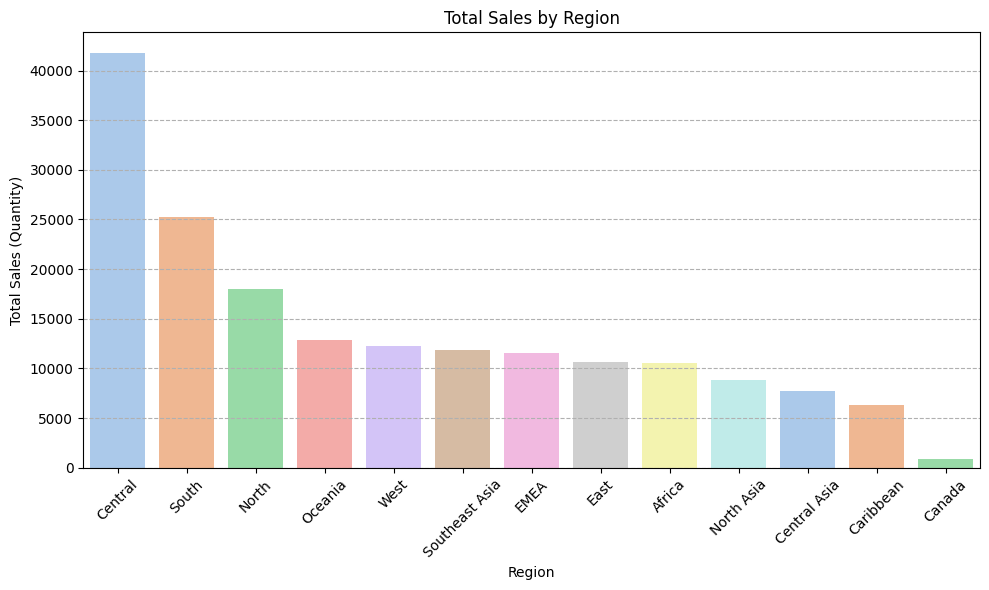

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Total_Sales', data=df10, palette='pastel')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales (Quantity)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


In [106]:
# Top 5 and Bottom Five cities by Profit
query11 = """
                WITH CityAvgProfit AS (
                  SELECT city, AVG(profit) AS AverageProfit
                  FROM superstore
                  GROUP BY city
                )
                SELECT *
                FROM (
                  SELECT city, AverageProfit as Top_Avg_Profit
                  FROM CityAvgProfit
                  ORDER BY AverageProfit DESC
                  LIMIT 5
                )
                UNION ALL
                SELECT *
                FROM (
                  SELECT city, AverageProfit as Top_Avg_Profit
                  FROM CityAvgProfit
                  ORDER BY AverageProfit ASC
                  LIMIT 5
                );"""

df11 = pd.read_sql(query11, conn)
print('Top 5 and Bottom 5 Cities by Profit\n')
df11

Top 5 and Bottom 5 Cities by Profit



,city,Top_Avg_Profit
0,Whakatane,1234.4400
1,Xingtai,1068.8400
2,Kamina,1068.6600
3,Salto,988.1200
4,Poitiers,953.2740
5,Ibb,-590.9760
6,Bergen op Zoom,-554.4090
7,Hardenberg,-538.6485
8,Bornova,-523.2935
9,San Severo,-447.1800


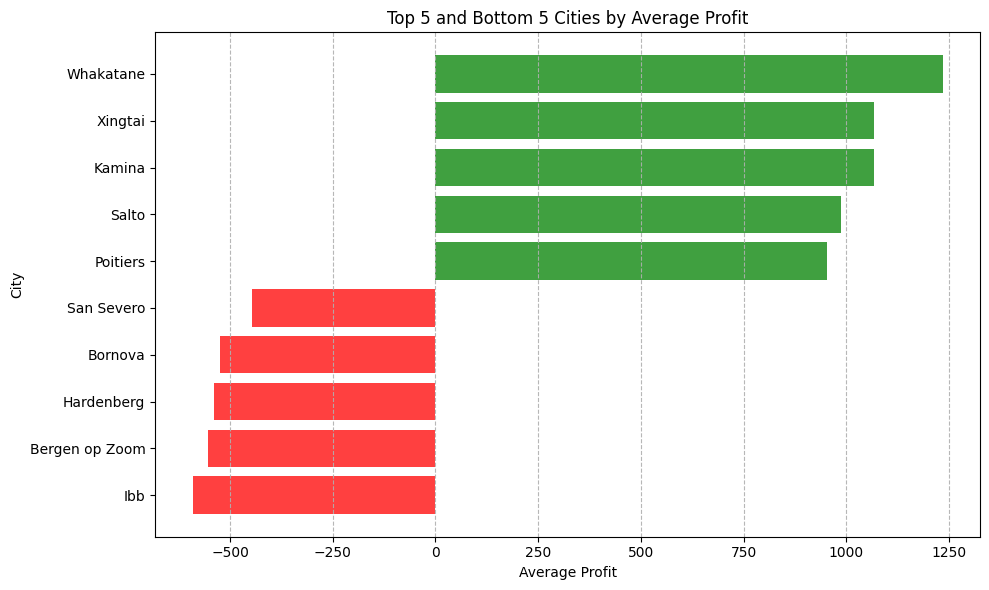

In [103]:
import matplotlib.pyplot as plt

df11_sorted = df11.sort_values(by='Top_Avg_Profit')

colors = df11_sorted['Top_Avg_Profit'].apply(lambda x: 'green' if x >= 0 else 'red')

plt.figure(figsize=(10, 6))
plt.barh(df11_sorted['city'], df11_sorted['Top_Avg_Profit'], color=colors, alpha=0.75)

plt.xlabel('Average Profit')
plt.ylabel('City')
plt.title('Top 5 and Bottom 5 Cities by Average Profit')

plt.grid(axis='x', linestyle='--', alpha=0.9)
plt.tight_layout()
plt.show()
